# Supplementary Fig. 15 — effect of the in-silico noise-reduction method on variant calls (top 10 CH genes)

Rescaled density of variants called across the **10 most commonly mutated clonal-haematopoiesis genes**
(DNMT3A, TET2, ASXL1, TP53, SRSF2, SF3B1, JAK2, IDH2, KRAS, CBL) vs variant allele frequency, for the
SLX_20124 pilot (**20 pre-AML + 20 controls**). Blue = UKCTOCS controls, red = UKCTOCS pre-AML; grey
markers and line are published comparison studies (Coombs 2017, Young 2016 & 2019, Desai 2018).

- **a** — *before* in-silico noise correction and post-processing.
- **b** — *after* in-silico noise correction and post-processing.

Both panels are restricted to SNVs: the noise correction is an SNV error model and the comparison studies
list no indels.

## Data availability

The per-sample DCS variant calls are individual-level participant data and are **not distributed with this
code** — they list every variant called in a named sample before germline filtering. The annotated tables
behind panel a are deposited under controlled access in the European Genome-phenome Archive and released to
approved researchers via a Data Access Committee; place them in the directory below and the panel runs
unchanged. The post-processed calls behind panel b are not deposited separately — they are rebuilt from the
same tables by the beta-binomial error model (`Duplex_Error_Model_initial_variant_calling_v5.py`, in the
[TETRIS-seq](https://github.com/the-blundell-lab/TETRIS-seq) repository) followed by
`Post_processing_variant_calls.ipynb` in this repository. The openly available somatic calls (Supplementary
Table 6, and the somatic VCFs on Zenodo) are not a shortcut: those are the final curated list, whereas this
panel needs the output of the automated step that precedes curation.

| file | used for | location |
|---|---|---|
| `Variant_calls_annotated_files/DCS/Pre-error model/*_variants_MUFs_3_annotated.txt` | per-sample calls before noise correction (panel a) | EGA, controlled access |
| `Variant_calls_annotated_files/DCS/Post-error model/*_all_non-germline_variant_calls_2026_post_processed.txt` | per-sample calls after noise correction (panel b) | regenerated, see above |
| `CH_studies/all_studies_trimmed_all_genes.csv` | published variant densities for the comparison studies | Data_files |
| `SLX_20124_sample_sheet.csv` | the 20 pre-AML and 20 control timepoints on the lane | Data_files |


## 1. Imports, colours, study totals

In [23]:
# imported packages
import csv
import math
import os
import re

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import integrate

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Helvetica'


In [24]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33);
c2 = (1.00, 0.23, 0.19);
c3 = (1.00, 0.58, 0.00);
c4 = (1.00, 0.80, 0.00);
c5 = (0.30, 0.85, 0.39);
c6 = (0.35, 0.78, 0.98);
c7 = (0.20, 0.67, 0.86);
c8 = (0.00, 0.48, 1.00);
c9 = (0.35, 0.34, 0.84);
c10 = (0.00, 0.31, 0.57);
c11 = (0.12, 0.29, 0.69);
c12 = (0.17, 0.17, 0.42);
c13 = (1.00, 1.00, 1.00);
c14 = (0.77, 0.04, 0.00);

In [25]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'
# yellow = '#ffffd4'

In [26]:
#Number of individuals in each study
Jaiswaltotal = 17182
Genovesetotal = 12380
McKerreltotal = 4219
Youngtotal = 20
Young2019totalcontrols = 69 #controls only
ZinkWGStotal = 11262
Acunatotal = 2006
Coombstotal = 1591 #chemotherapy and radiotherapy naive individuals
Desaitotal = 181 #controls only

In [27]:
axisfont=13
titlefont=20
subtitlefont = 15
axislabelfont=15
legendfont = 11
tpfont = 12

In [28]:
top_10_mu = 3.8011236665e-05  # panel mutation rate for the 10 CH genes (pre-computed)

## 2. Comparison-study variant lists (Coombs / Young / Desai)

In [29]:
# Create dictionaries for Young, Coombs and Desai containing variants in top 10 genes
filename="Data_files/CH_studies/all_studies_trimmed_all_genes.csv"

with open(filename, 'r') as csvfile:
    read_reader = csv.reader(csvfile)  #csv.reader returns a reader object which will iterate over lines in the csvfile
    row_count=0
    top_10_CH_results_Coombs={} #dictionary of DNMTA results (key = ID (row[13]), value = VAF (row[10]))
    top_10_CH_results_Young={} #dictionary of DNMTA results (key = ID (row[13]), value = VAF (row[10]))
    top_10_CH_results_Desai={} #dictionary of DNMTA results (key = ID (row[13]), value = VAF (row[10]))
    
    for row in read_reader:
        if row_count>0:
            if row[3]=='DNMT3A':
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if study == 'Coombs2017':
                    top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                if study == 'Young2019':
                    top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                if study == 'Young2016':
                    top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                if study == 'Desai2018':
                    top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)

            if row[3]=='TET2':
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if study == 'Coombs2017':
                    top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                if study == 'Young2019':
                    top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                if study == 'Young2016':
                    top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                if study == 'Desai2018':
                    top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)
                    
            if row[3]=='ASXL1':
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if codon_number >573:
                    if study == 'Coombs2017':
                        top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                    if study == 'Young2019':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Young2016':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Desai2018':
                        top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)
                    
            if row[3]=='JAK2':
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if 592 <codon_number <623: #exon12
                    if study == 'Coombs2017':
                        top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                    if study == 'Young2019':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Young2016':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Desai2018':
                        top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)
                if 664 <codon_number <772: #exon14
                    if study == 'Coombs2017':
                        top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                    if study == 'Young2019':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Young2016':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Desai2018':
                        top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)
                        
            if row[3]=='TP53':
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if study == 'Coombs2017':
                    top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                if study == 'Young2019':
                    top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                if study == 'Young2016':
                    top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                if study == 'Desai2018':
                    top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)
                    
            if row[3]=='SF3B1':
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if 573 < codon_number <791:
                    if study == 'Coombs2017':
                        top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                    if study == 'Young2019':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Young2016':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Desai2018':
                        top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)
                        
            if row[3]=='KRAS':
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if codon_number <98: #exons 2-3
                    if study == 'Coombs2017':
                        top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                    if study == 'Young2019':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Young2016':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Desai2018':
                        top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)
                    
            if row[3]=='CBL':
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if 365 < codon_number <478: #exons 8-9
                    if study == 'Coombs2017':
                        top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                    if study == 'Young2019':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Young2016':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Desai2018':
                        top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)

            if row[3]=='SRSF2':
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if codon_number < 122: #exon 1
                    if study == 'Coombs2017':
                        top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                    if study == 'Young2019':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Young2016':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Desai2018':
                        top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)   
                        
            if row[3]=='IDH2': #exon 4
                VAF = float(row[0])
                age = row[1]
                variant = row[2]
                codon_number = int(((re.findall(r'\d+', variant)))[0])
                study = row[4]
                gene = row[3]
                if 124 < codon_number < 178:
                    if study == 'Coombs2017':
                        top_10_CH_results_Coombs[row_count] = (gene, VAF, variant, codon_number, age, study)
                    if study == 'Young2019':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Young2016':
                        top_10_CH_results_Young[row_count] = (gene, VAF, variant, codon_number,age, study)
                    if study == 'Desai2018':
                        top_10_CH_results_Desai[row_count] = (gene, VAF, variant, codon_number,age, study)   

        row_count=row_count+1

In [30]:
# Comparison-study VAF lists for the top-10 CH genes (Coombs / Young / Desai).
Young_top_10_list = []
Desai_top_10_list = []
Coombs_top_10_list = []
for (row_count, VAF) in top_10_CH_results_Coombs.items():
    Coombs_top_10_list.append(VAF[1])
for (row_count, VAF) in top_10_CH_results_Young.items():
    Young_top_10_list.append(VAF[1])
for (row_count, VAF) in top_10_CH_results_Desai.items():
    Desai_top_10_list.append(VAF[1])


## 3. UKCTOCS per-sample VAFs (SLX_20124): pre- and post-correction

In [31]:
def create_list_of_cases_and_controls(library, samples_to_exclude):
    cases = []
    controls = []

    sample_names_csv = 'Data_files/'+library+'_sample_sheet.csv'
    with open(sample_names_csv) as csv_file:
        reader = csv.reader(csv_file)
        for row in reader:
            if library == 'SLX_19284': #SLX_19284 sample names do not have _SNV on the end
                sample_name = row[0]
                if sample_name not in samples_to_exclude:
                    if sample_name+'_SNV' not in samples_to_exclude: 
                        if 'C92' in sample_name:
                            cases.append(sample_name)
                        else:
                            controls.append(sample_name)
            else:
                sample_name = row[0].split('_SNV')[0]
                if sample_name not in samples_to_exclude:
                    if 'C92' in sample_name:
                        cases.append(sample_name)
                    else:
                        controls.append(sample_name)
                    
    cases_and_controls = cases+controls
    print('number of cases included = ', len(cases))
    print('number of controls included = ', len(controls))

    return cases_and_controls

In [32]:
cases_and_controls = create_list_of_cases_and_controls('SLX_20124', [])

number of cases included =  20
number of controls included =  20


In [ ]:
def create_sample_df_with_names(sample_name, SSCS_or_DCS, library):
#     print(sample_name)
    #the post-processing output, in which germline and somatic calls are separated
    vcf_path = ('Data_files/Variant_calls_annotated_files/'+SSCS_or_DCS+'/Post-error model/'+sample_name+
                '_SNV_watson_code_'+SSCS_or_DCS+'_MUFs_3_beta_binomial_SNV_all_non-germline_variant_calls_2026_post_processed.txt')

    if not os.path.exists(vcf_path):
        raise FileNotFoundError('no variant-call file for '+sample_name+' at '+vcf_path)
    if os.path.getsize(vcf_path) == 0:
        raise ValueError('variant-call file for '+sample_name+' is empty: '+vcf_path)

    df = pd.read_csv(vcf_path, index_col=False, delimiter = '\t', comment='#')

    df_nonsyn = df[df['exonic_function'].isin(['nonsynonymous SNV', 'stopgain'])]
    df_nonsyn = df_nonsyn[df_nonsyn['RSID']=='-']
    #'.' means 'not in ExAC'; to_numeric avoids the deprecated silent downcast of .replace
    df_nonsyn['exac_all']= pd.to_numeric(df_nonsyn['exac_all'], errors='coerce').fillna(0)
    df_nonsyn = df_nonsyn[df_nonsyn['exac_all']<=0.001]

    #SNVs only: the in-silico noise correction is an SNV error model (indels are called separately
    #by VarDictJava and never pass through it), and the Coombs/Young/Desai comparison lists contain
    #no indels. Most 'stopgain' calls are nonsense SNVs and are kept; this drops only the small number
    #of indels that create a premature stop codon and so are also annotated 'stopgain'.
    df_nonsyn = df_nonsyn[df_nonsyn['variant_type']=='SNV']

    DNMT3A_variants = df_nonsyn[df_nonsyn['gene']=='DNMT3A']['VAF'].values.tolist()
    TET2_variants = df_nonsyn[df_nonsyn['gene']=='TET2']['VAF'].values.tolist()
    ASXL1_variants = df_nonsyn[(df_nonsyn['gene']=='ASXL1') & (df_nonsyn['exon']=='exon12')]['VAF'].values.tolist()
    JAK2_variants = df_nonsyn[(df_nonsyn['gene']=='JAK2') & (df_nonsyn['exon'].isin(['exon12', 'exon14']))]['VAF'].values.tolist()
    TP53_variants = df_nonsyn[df_nonsyn['gene']=='TP53']['VAF'].values.tolist()
    SF3B1_variants = df_nonsyn[(df_nonsyn['gene']=='SF3B1') & (df_nonsyn['exon'].isin(['exon13', 'exon14', 'exon15', 'exon16']))]['VAF'].values.tolist()
    KRAS_variants = df_nonsyn[df_nonsyn['gene']=='KRAS']['VAF'].values.tolist()
    CBL_variants = df_nonsyn[(df_nonsyn['gene']=='CBL') & (df_nonsyn['exon'].isin(['exon8', 'exon9']))]['VAF'].values.tolist()
    SRSF2_variants = df_nonsyn[(df_nonsyn['gene']=='SRSF2') & (df_nonsyn['exon']=='exon1')]['VAF'].values.tolist()
    IDH2_variants = df_nonsyn[(df_nonsyn['gene']=='IDH2') & (df_nonsyn['exon']=='exon4')]['VAF'].values.tolist()
    

    non_syn_variants = DNMT3A_variants+TET2_variants+ASXL1_variants+JAK2_variants+TP53_variants+SF3B1_variants+KRAS_variants+CBL_variants+SRSF2_variants+IDH2_variants

    return non_syn_variants

In [34]:
def create_sample_df_with_names_preprocessing(sample_name, SSCS_or_DCS, library):
#     print(sample_name)
    stem = 'Data_files/Variant_calls_annotated_files/'+SSCS_or_DCS+'/Pre-error model/'+sample_name
    vcf_path = stem+'_SNV_SNV_watson_code_'+SSCS_or_DCS+'_variants_MUFs_3_annotated.txt'
    if not os.path.exists(vcf_path):
        vcf_path = stem+'_SNV_watson_code_'+SSCS_or_DCS+'_variants_MUFs_3_annotated.txt'
    
    if not os.path.exists(vcf_path):
        raise FileNotFoundError('no variant-call file for '+sample_name+' at '+vcf_path)
    if os.path.getsize(vcf_path) == 0:
        raise ValueError('variant-call file for '+sample_name+' is empty: '+vcf_path)

    df = pd.read_csv(vcf_path, index_col=False, delimiter = '\t', comment='#')

    df_nonsyn = df[df['exonic_function'].isin(['nonsynonymous SNV', 'stopgain'])]
    df_nonsyn = df_nonsyn[df_nonsyn['RSID']=='-']
    #'.' means 'not in ExAC'; to_numeric avoids the deprecated silent downcast of .replace
    df_nonsyn['exac_all']= pd.to_numeric(df_nonsyn['exac_all'], errors='coerce').fillna(0)
    df_nonsyn = df_nonsyn[df_nonsyn['exac_all']<=0.001]

    #SNVs only: the in-silico noise correction is an SNV error model (indels are called separately
    #by VarDictJava and never pass through it), and the Coombs/Young/Desai comparison lists contain
    #no indels. Most 'stopgain' calls are nonsense SNVs and are kept; this drops only the small number
    #of indels that create a premature stop codon and so are also annotated 'stopgain'.
    df_nonsyn = df_nonsyn[df_nonsyn['variant_type']=='SNV']

    DNMT3A_variants = df_nonsyn[df_nonsyn['gene']=='DNMT3A']['VAF'].values.tolist()
    TET2_variants = df_nonsyn[df_nonsyn['gene']=='TET2']['VAF'].values.tolist()
    ASXL1_variants = df_nonsyn[(df_nonsyn['gene']=='ASXL1') & (df_nonsyn['exon']=='exon12')]['VAF'].values.tolist()
    JAK2_variants = df_nonsyn[(df_nonsyn['gene']=='JAK2') & (df_nonsyn['exon'].isin(['exon12', 'exon14']))]['VAF'].values.tolist()
    TP53_variants = df_nonsyn[df_nonsyn['gene']=='TP53']['VAF'].values.tolist()
    SF3B1_variants = df_nonsyn[(df_nonsyn['gene']=='SF3B1') & (df_nonsyn['exon'].isin(['exon13', 'exon14', 'exon15', 'exon16']))]['VAF'].values.tolist()
    KRAS_variants = df_nonsyn[df_nonsyn['gene']=='KRAS']['VAF'].values.tolist()
    CBL_variants = df_nonsyn[(df_nonsyn['gene']=='CBL') & (df_nonsyn['exon'].isin(['exon8', 'exon9']))]['VAF'].values.tolist()
    SRSF2_variants = df_nonsyn[(df_nonsyn['gene']=='SRSF2') & (df_nonsyn['exon']=='exon1')]['VAF'].values.tolist()
    IDH2_variants = df_nonsyn[(df_nonsyn['gene']=='IDH2') & (df_nonsyn['exon']=='exon4')]['VAF'].values.tolist()
    

    non_syn_variants = DNMT3A_variants+TET2_variants+ASXL1_variants+JAK2_variants+TP53_variants+SF3B1_variants+KRAS_variants+CBL_variants+SRSF2_variants+IDH2_variants

    return non_syn_variants

In [35]:
UKCTOCs_cases_VAFs = []
UKCTOCs_controls_VAFs = []

n_cases = n_controls = 0

for sample in cases_and_controls:
    if 'CNTRL' in sample:
        n_controls += 1
        VAFs = create_sample_df_with_names(sample, 'DCS', 'SLX_20124')
        for i in VAFs:
            if i <=0.45:
                UKCTOCs_controls_VAFs.append(i)
    else:
        n_cases += 1
        VAFs = create_sample_df_with_names(sample, 'DCS', 'SLX_20124')
        for i in VAFs:
            if i<=0.45:
                UKCTOCs_cases_VAFs.append(i)
            

print(f'panel b (after noise correction): {n_cases} pre-AML and {n_controls} control samples contributed ({len(UKCTOCs_cases_VAFs)} and {len(UKCTOCs_controls_VAFs)} variants)')

panel b (after noise correction): 20 pre-AML and 20 control samples contributed (29 and 19 variants)


In [36]:
UKCTOCs_cases_VAFs_preprocessing = []
UKCTOCs_controls_VAFs_preprocessing = []

n_cases = n_controls = 0

for sample in cases_and_controls:
    if 'CNTRL' in sample:
        n_controls += 1
        VAFs = create_sample_df_with_names_preprocessing(sample, 'DCS', 'SLX_20124')
        for i in VAFs:
            if i <=0.45:
                UKCTOCs_controls_VAFs_preprocessing.append(i)
    else:
        n_cases += 1
        VAFs = create_sample_df_with_names_preprocessing(sample, 'DCS', 'SLX_20124')
        for i in VAFs:
            if i<=0.45:
                UKCTOCs_cases_VAFs_preprocessing.append(i)
            

print(f'panel a (before noise correction): {n_cases} pre-AML and {n_controls} control samples contributed ({len(UKCTOCs_cases_VAFs_preprocessing)} and {len(UKCTOCs_controls_VAFs_preprocessing)} variants)')

panel a (before noise correction): 20 pre-AML and 20 control samples contributed (16156 and 19482 variants)


## 4. Plotting helpers

In [37]:
def error_bars(hist, normed_value, widths):
    
    errors={}
    n=0
    for i in list(hist):
        normalised_hist = i/(normed_value*widths)
        #empty bins give log(0) = -inf, which matplotlib drops; see error_bars()
        with np.errstate(divide='ignore'):
            log_hist = np.log(normalised_hist)
        sqrt_hist = math.sqrt(i)
        if sqrt_hist == 1:
            upper_error = 1
            lower_error = 0.9
        if sqrt_hist !=1:
            upper_error = sqrt_hist
            lower_error = sqrt_hist
        normalised_upper_error = upper_error/(normed_value*widths)
        normalised_lower_error = lower_error/(normed_value*widths)
        errors[n]=(normalised_hist[0], normalised_upper_error[0], normalised_lower_error[0])
        n = n+1

    errors_corrected ={}
    #empty bins give log(0) = -inf and log(negative) = nan; matplotlib drops those points,
    #so the warnings they raise are expected and silenced here rather than globally
    with np.errstate(divide='ignore', invalid='ignore'):
        for k, v in errors.items():
            binheight = v[0]
            log_binheight = np.log(v[0])
            upper_error = v[1]
            lower_error = v[2]
            log_upper_error = (np.log(upper_error+binheight))-log_binheight
            log_lower_error = log_binheight-(np.log(binheight-lower_error))
            errors_corrected[k] = (log_binheight, log_upper_error, log_lower_error)

    lower_err=[]
    upper_err=[]
    for k, v in errors_corrected.items():
        lower_error = v[2]
        upper_error = v[1]
        lower_err.append(lower_error)
        upper_err.append(upper_error)

    err = [tuple(lower_err),tuple(upper_err)]
    
    return err

In [38]:
def log_hist_data_for_plot(study_VAFs, study_total, study_mu, bin_size):
    log_VAFs = []
    for i in study_VAFs:
        log_VAFs.append(np.log(float(i)))
    normed_value = study_total*2*study_mu
#     bin_size = int((max(log_VAFs)-min(log_VAFs))/(1/((len(log_VAFs))**(1/3))))
    hist, bins = np.histogram(log_VAFs, bins=bin_size, range=(min(log_VAFs),max(log_VAFs)))
    widths = np.diff(bins)
    bin_centres = (bins[:-1] + bins[1:])/2
    hist = np.array(hist, dtype=float)
    normalised_hist = hist/(normed_value*widths)
    #empty bins give log(0) = -inf, which matplotlib drops; see error_bars()
    with np.errstate(divide='ignore'):
        log_hist_for_plot = np.log(normalised_hist)
    
    errors = error_bars(hist, normed_value, widths)
    
    return bin_centres, log_hist_for_plot, errors

In [47]:
def plot_log_hist_data_for_plot_solid(study_VAFs, study_total, study_mu, bin_size, study_name, marker_name, marker_size, color, zorder):
    log_VAFs = []
    for i in study_VAFs:
        log_VAFs.append(np.log(float(i)))
    normed_value = study_total*2*study_mu
    hist, bins = np.histogram(log_VAFs, bins=bin_size, range=(min(log_VAFs),max(log_VAFs)))
    widths = np.diff(bins)
    bin_centres = (bins[:-1] + bins[1:])/2
    hist = np.array(hist, dtype=float)
    normalised_hist = hist/(normed_value*widths)
    #empty bins give log(0) = -inf, which matplotlib drops; see error_bars()
    with np.errstate(divide='ignore'):
        log_hist_for_plot = np.log(normalised_hist)
    
    errors = error_bars(hist, normed_value, widths)
    
    axisfont=14*scale
    axislabelfont=15*scale
    tpfont = 14*scale

    m_size = 12*scale
    m_width = 1.5*scale
    c_size = 3*scale
    c_thick = 1.5*scale
    e_width = 1.5*scale

#     Jaiswalmarker = 'o'
#     Zinkmarker = '^'
#     Acunamarker = 'P'
    Coombsmarker = 'v'
    Youngmarker = 'p'
#     Mckerrelmarker = 'D'
#     Genovesemarker = 'd'
    Desaimarker = '*'
    UKCTOCs_control_marker = 'o'
    UKCTOCs_case_marker = 'D'

    #Colors
    DNMT3A_color = 'dodgerblue'
    R882_color = c1
    neutralcolor = c3
    
    #Plot
    ax1.errorbar(bin_centres, log_hist_for_plot, yerr= errors, fmt = marker_name, ecolor = color, \
             elinewidth = e_width, capsize = c_size, capthick = c_thick, markersize = marker_size, markeredgewidth = m_width, \
             markeredgecolor = color, markerfacecolor = color, label = study_name, zorder = zorder)
    
    # Set axis limits
    ax1.set_ylim(1, 17)
    ax1.set_xlim(-9, 0)
    # ax1.set_xlim(-7.6, 0)

    # Axis labels
    ax1.set_xlabel('variant allele frequency (%)', fontsize = axislabelfont, labelpad = 6*scale, fontweight = 'medium')
    ax1.set_ylabel('rescaled density', fontsize = axislabelfont, labelpad = 6*scale, fontweight = 'medium')

    x_major_ticks = [np.log(0.0001),np.log(0.0002),np.log(0.0003),np.log(0.0004),np.log(0.0005),np.log(0.0006),np.log(0.0007),np.log(0.0008), np.log(0.0009),\
                     np.log(0.001), np.log(0.002),np.log(0.003),np.log(0.004),np.log(0.005),np.log(0.006),np.log(0.007),np.log(0.008),np.log(0.009), \
                     np.log(0.01),np.log(0.02),np.log(0.03),np.log(0.04),np.log(0.05),np.log(0.06),np.log(0.07),np.log(0.08),np.log(0.09),\
                     np.log(0.1),np.log(0.2),np.log(0.3),np.log(0.4),np.log(0.5),np.log(0.6),np.log(0.7),np.log(0.8),np.log(0.9), np.log(1.0)]
    x_major_tick_labels = ["0.01","","","","","","","","",\
                           "0.1","","","","","","","","",\
                           "1","","","","","","","","",\
                           "10","","","","50","","","","",""]
    ax1.set_xticks(x_major_ticks)
    ax1.set_xticklabels(x_major_tick_labels, fontsize = axisfont)
    ax1.xaxis.set_tick_params(width=scale, color = grey3, length = 6)

    y_major_ticks = [np.log(1), np.log(2), np.log(3), \
                     np.log(4), np.log(5), np.log(6), \
                     np.log(7), np.log(8), np.log(9), \
                     np.log(10), np.log(20), np.log(30),\
                     np.log(40), np.log(50), np.log(60), \
                     np.log(70), np.log(80), np.log(90),\
                     np.log(100), np.log(200), np.log(300), \
                     np.log(400), np.log(500), np.log(600),\
                     np.log(700), np.log(800), np.log(900), \
                     np.log(1000), np.log(2000), np.log(3000),\
                    np.log(4000), np.log(5000), np.log(6000), \
                     np.log(7000), np.log(8000), np.log(9000),\
                    np.log(10000), np.log(20000), np.log(30000), \
                     np.log(40000), np.log(50000), np.log(60000),\
                    np.log(70000), np.log(80000), np.log(90000), \
                     np.log(100000), np.log(200000),np.log(300000),np.log(400000),np.log(500000),np.log(600000),\
                    np.log(700000),np.log(800000),np.log(900000),np.log(1000000),
                    np.log(2000000),np.log(3000000),np.log(4000000),np.log(5000000),np.log(6000000),\
                    np.log(7000000),np.log(8000000),np.log(9000000),np.log(10000000),]
    y_major_tick_labels = ["","","", "", "", "", "", "", "", "$10^{1}$","", "", "", "", "", "", "", "", \
                           "$10^{2}$","", "", "", "", "", "", "", "", "$10^{3}$","", "", "", "", "", "", "", "", \
                           "$10^{4}$","", "", "", "", "", "", "", "", "$10^{5}$","", "", "", "", "", "", "", "", "$10^{6}$", 
                           "", "", "", "", "", "", "", "", "$10^{7}$"]
    ax1.set_yticks(y_major_ticks)
    ax1.set_yticklabels(y_major_tick_labels, fontsize = axisfont)
    ax1.yaxis.set_tick_params(width=scale, color = grey3, length = 6)

    #Only show the required axis lines
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    for axis in ['bottom','left']:
        ax1.spines[axis].set_linewidth(scale)

    for axis in ['bottom','left']:
        ax1.spines[axis].set_color(grey3)
        
    
    #set panel legends
    legend_marker_size = 8*scale
    legend_elements = [Line2D([0], [0], marker = Coombsmarker, color=grey3, alpha=0.4, markersize = legend_marker_size*1.2, \
                              lw=0, label='Coombs 2017'),
                      Line2D([0], [0], marker = Youngmarker, color=grey3, alpha=0.4, markersize = legend_marker_size*1.2, \
                              lw=0, label='Young 2016 & 2019'),
                       Line2D([0], [0], marker = Desaimarker, color=grey3, alpha=0.4, markersize = legend_marker_size*1.5, \
                              lw=0, label='Desai 2018')]

    ax1.legend(ncol=1, handles=legend_elements, loc='center', bbox_to_anchor=(0.12, 0.12), frameon=0, fontsize = 11*scale)
    
    return ax1

In [48]:
# MLE function for range of ages with EXPONENTIAL POWER DISTRIBUTION
#l=ln(f)

def logProbtheory_ages_nonsyn_exp_power(l, params): #= predicted density (i.e. normalised by 2 x mu)
    "Natural log of the probability of observing a variant within a specific binwidth if able to sequence perfectly"
    total_density=0.0
    s_peak = 0.0
    b = params[0]
    d = params[1]
    s_max = params[2]

    N = 9.40166610e+04
    sigma = 1.14417164e+01
    
    mean=55
    dt=0.1
#     s_max=0.25
    
    weight_s= lambda s: np.exp(-((abs(s-s_peak))/d)**b)
    normalization=integrate.quad(weight_s, 0.0, s_max)
    normalized_rho_s= lambda s: (1.0/normalization[0])*np.exp(-((abs(s-s_peak))/d)**b)
    
    rho=lambda t,s: (normalized_rho_s(s))*(N/(1-2*np.exp(l))*np.exp(-((np.exp(l))/(((np.exp(s*t)-1)/(2*N*s))*(1-2*np.exp(l))))))*((1/((2*np.pi*(sigma)**2)**0.5))*(np.exp(-(t-mean)**2/(2*(sigma**2)))))

    total_density=integrate.dblquad(rho, 0.0, s_max, lambda s: mean-2*sigma, lambda s: mean+2*sigma)

    return np.log(total_density[0])

def logProbDataGivenModel_ages_nonsyn_exp_power(params, data): #d = data (number of variants within a given bin), lamb (lambda) = expected number of variants in the bin from theory
    "This returns the natural log likelihood of the entire data, in specified binwidths, for a given theta and phi"
    total_square_distance = 0
    for datapoint in data:
        if np.exp(datapoint[0])<0.5:
            logfreq = datapoint[0]
            predicted_log_density = logProbtheory_ages_nonsyn_exp_power(logfreq, params)
            square_distance = ((datapoint[1] - predicted_log_density)**2)
            total_square_distance = total_square_distance + square_distance
                
    return total_square_distance   

In [41]:
binmethod = 'doane'  # histogram bin rule

## 5. Panel a — before in-silico noise correction

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


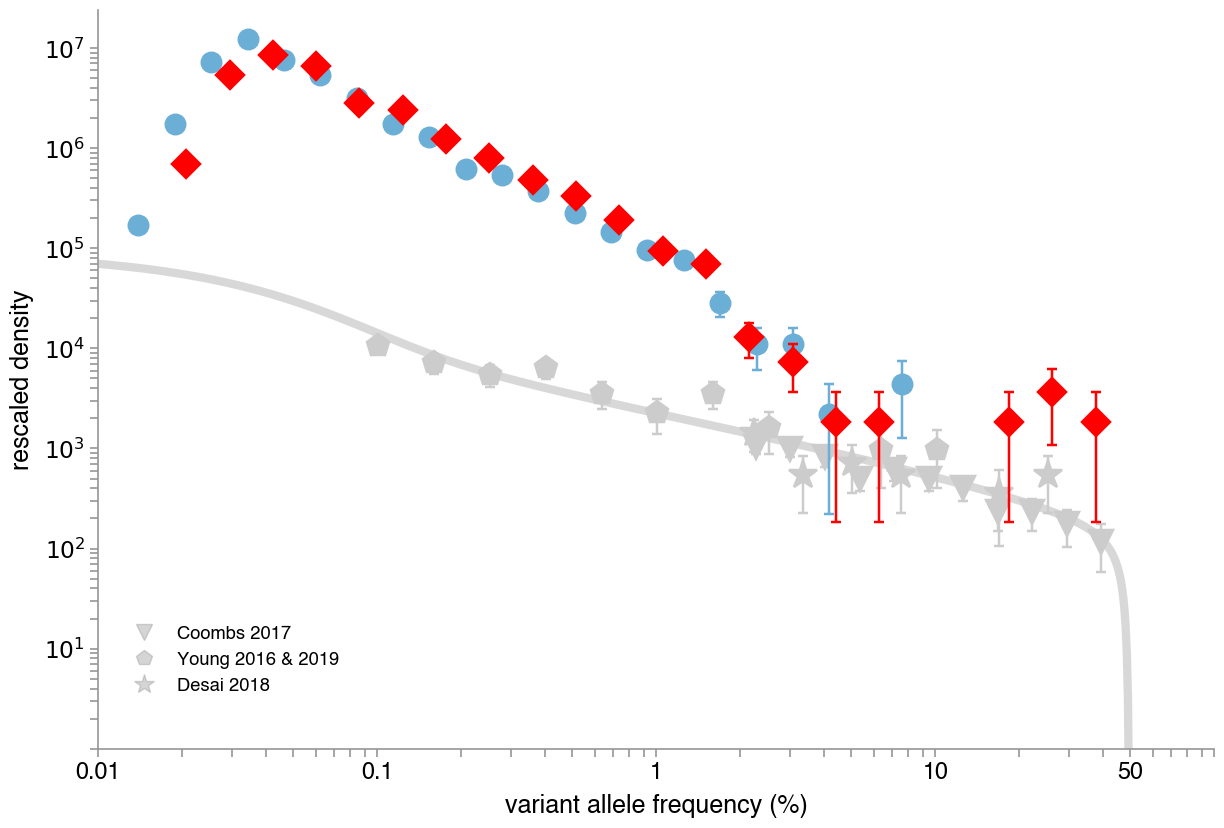

In [ ]:
#Plotting the histogram
plt.close('all')
scale = 1.2
f, (ax1) = plt.subplots(1, 1, sharey=True, figsize=(12*scale, 8*scale))

m_size = 14
Coombsmarkersize = m_size*1.2
Youngmarkersize = m_size*1.2
Desaimarkersize = m_size*1.5

N = 9.40166610e+04
sd_ages = 1.14417164e+01
mean_age = 55

line_width = 6
a = 0.75

# top10color = '#980043'
top10color = grey2

Jaiswalmarker = 'o'
Zinkmarker = '^'
Acunamarker = 'P'
Coombsmarker = 'v'
Youngmarker = 'p'
Mckerrelmarker = 'D'
Genovesemarker = 'd'
Desaimarker = '*'

b = 3.27535774e-01
d = 3.01655956e-04
s_max = 1.61181839e-01

x=np.linspace(-10, np.log(0.499), 1000)
y_intuitive=[logProbtheory_ages_nonsyn_exp_power(l, [b, d, s_max]) for l in x]
ax1.plot(x, y_intuitive, c = top10color, lw = line_width, alpha = a, zorder = 0)

#top10
plot_log_hist_data_for_plot_solid(Coombs_top_10_list, Coombstotal, top_10_mu, binmethod, \
                            'Coombs 2017', Coombsmarker, Coombsmarkersize, top10color, 1)
plot_log_hist_data_for_plot_solid(Young_top_10_list, Youngtotal+Young2019totalcontrols, top_10_mu, binmethod, \
                            'Young 2016 & 2019', Youngmarker, Youngmarkersize, top10color, 2)
plot_log_hist_data_for_plot_solid(Desai_top_10_list, Desaitotal, top_10_mu, binmethod, \
                            'Desai 2018', Desaimarker, Desaimarkersize, top10color, 3)

plot_log_hist_data_for_plot_solid(UKCTOCs_controls_VAFs_preprocessing, 20, top_10_mu, binmethod, \
                            'UKCTOCs controls', 'o', m_size, blue3, 4)
plot_log_hist_data_for_plot_solid(UKCTOCs_cases_VAFs_preprocessing, 20, top_10_mu, binmethod, \
                            'UKCTOCs cases', 'D', m_size, 'red', 5)


plt.show()

## 6. Panel b — after in-silico noise correction

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


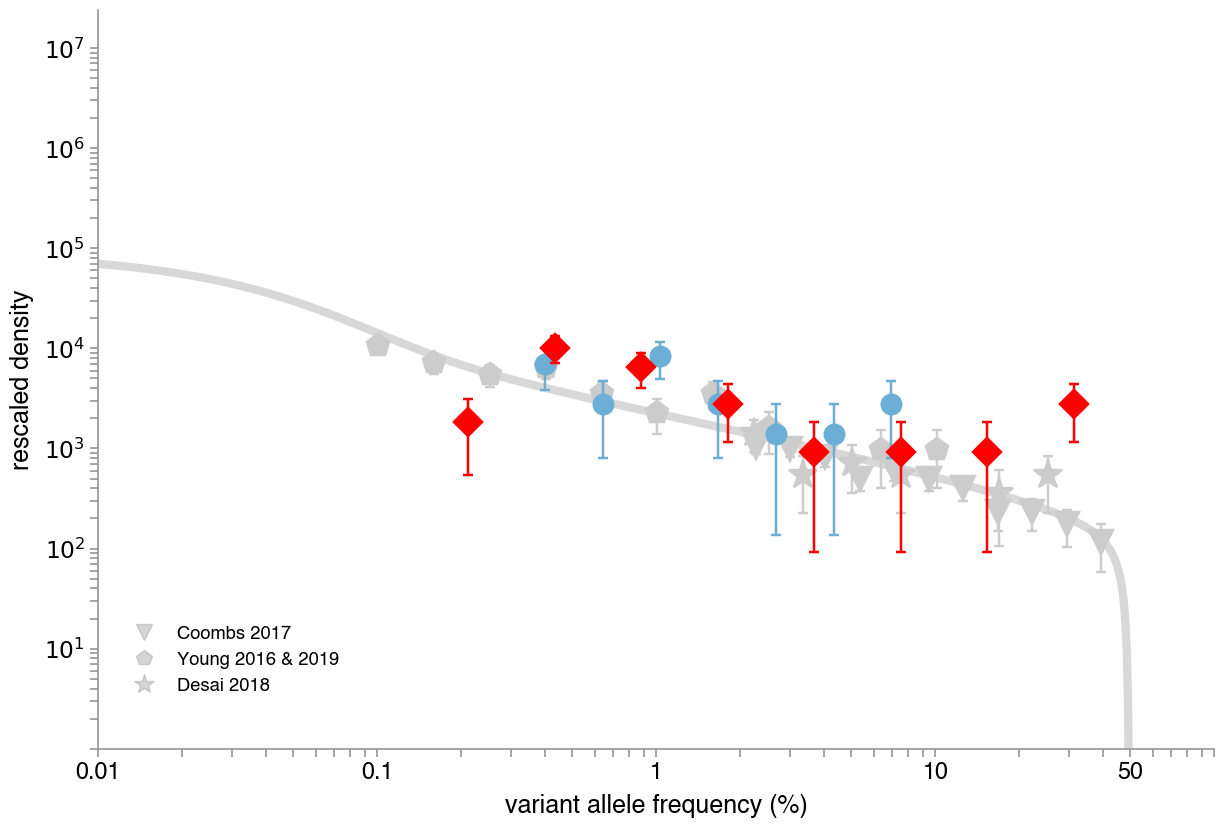

In [ ]:
#Plotting the histogram
plt.close('all')
scale = 1.2
f, (ax1) = plt.subplots(1, 1, sharey=True, figsize=(12*scale, 8*scale))

m_size = 14
Coombsmarkersize = m_size*1.2
Youngmarkersize = m_size*1.2
Desaimarkersize = m_size*1.5

N = 9.40166610e+04
sd_ages = 1.14417164e+01
mean_age = 55

line_width = 6
a = 0.75

# top10color = '#980043'
top10color = grey2

Jaiswalmarker = 'o'
Zinkmarker = '^'
Acunamarker = 'P'
Coombsmarker = 'v'
Youngmarker = 'p'
Mckerrelmarker = 'D'
Genovesemarker = 'd'
Desaimarker = '*'

b = 3.27535774e-01
d = 3.01655956e-04
s_max = 1.61181839e-01

x=np.linspace(-10, np.log(0.499), 1000)
y_intuitive=[logProbtheory_ages_nonsyn_exp_power(l, [b, d, s_max]) for l in x]
ax1.plot(x, y_intuitive, c = top10color, lw = line_width, alpha = a, zorder = 0)

#top10
plot_log_hist_data_for_plot_solid(Coombs_top_10_list, Coombstotal, top_10_mu, binmethod, \
                            'Coombs 2017', Coombsmarker, Coombsmarkersize, top10color, 1)
plot_log_hist_data_for_plot_solid(Young_top_10_list, Youngtotal+Young2019totalcontrols, top_10_mu, binmethod, \
                            'Young 2016 & 2019', Youngmarker, Youngmarkersize, top10color, 2)
plot_log_hist_data_for_plot_solid(Desai_top_10_list, Desaitotal, top_10_mu, binmethod, \
                            'Desai 2018', Desaimarker, Desaimarkersize, top10color, 3)

plot_log_hist_data_for_plot_solid(UKCTOCs_controls_VAFs, 20, top_10_mu, binmethod, \
                            'UKCTOCs controls', 'o', m_size, blue3, 4)

plot_log_hist_data_for_plot_solid(UKCTOCs_cases_VAFs, 20, top_10_mu, binmethod, \
                            'UKCTOCs cases', 'D', m_size, 'red', 5)

plt.show()